# acquire

> pull the web, papers, video, files, code and JSON APIs into the vault, once or on a schedule

In [ ]:
#| default_exp acquire

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

Every method is one [fossick](https://github.com/vedicreader/fossick) call plus `Vault.add`. fossick fetches; the vault files with provenance.


In [ ]:
#| export
import hashlib, json, re, time, uuid, warnings
from tempfile import mkdtemp
from urllib.parse import urlparse
from fastcore.all import AttrDict, L, Path, chunked, first, patch
from fossick import json_records, md_title, read, what_is
from litesearch import code_exts, dir2files, pdf_parse, DOC_EXTS
from vishalakshi.core import Vault, KINDS, is_sanskrit_file
from pobblebonk import Pob, secs

In [ ]:
#| export
def clip(s:str, n:int=120) -> str:
    'Collapse whitespace and clip a scraped title to something a breadcrumb can carry.'
    return re.sub(r'\s+', ' ', (s or '').strip())[:n] or 'untitled'

#: What `fossick.read` calls a target, and what the vault files it as. A file from GitHub is a
#: web document here: its provenance is the URL, not the checkout.
KIND_OF = dict(web='web', arxiv='arxiv', youtube='youtube', ghfile='web', pdf='pdf', file='file')

`url(..., auto=True)` retries past bot-wall challenge pages (HTTP 200 with no article). `web` stores the discovery query in meta so `sources()` still explains why a page is here.


In [ ]:
#| export
@patch
def _file(self:Vault,
          r,                  # what `fossick.read` returned
          kind:str=None,      # override the kind it named
          title:str=None,     # override the title it found
          meta:dict=None,     # merged over the reader's own provenance
          force:bool=False,   # re-ingest a source already present
          **kw                # forwarded to `add`
) -> dict:
    'File a `fossick.read` result. The one place a fetched thing becomes a document.'
    if not r.ok: return dict(source=r.source, skipped=r.skipped, title=r.title or None)
    return dict(self.add(r.text, title or clip(r.title), source=r.source,
                         kind=kind or KIND_OF.get(r.kind, 'web'),
                         meta=dict(meta or {}, url=r.source, **r.meta), force=force, **kw),
                url=r.source)

@patch
def url(self:Vault,
        url:str,            # page to read
        title:str=None,     # defaults to the page's first heading, else its path
        sel:str=None,       # CSS selector to narrow the page before conversion
        kind:str='web',
        auto:bool=True,     # escalate plain -> heavy -> stealthy -> logged-in Chrome past bot walls
        meta:dict=None,
        force:bool=False,
        **kw                # forwarded to fossick.fetch (verify=, headers=, heavy=…)
) -> dict:
    'Fetch one URL, convert it to markdown and file it in the vault.'
    return self._file(read(url, sel=sel, auto=auto, **kw), kind=kind, title=title,
                      meta=meta, force=force)

@patch
def crawl(self:Vault, start_url:str, max_pages:int=10, sel:str=None, **kw) -> L:
    'Crawl a docs site or blog from a start URL and file every page in the vault.'
    from fossick import crawl as _crawl, to_md
    pgs = L((pg.url, to_md(pg, sel=sel)) for pg in _crawl(start_url, sel=sel, max_pages=max_pages, **kw))
    return L(self.add(md, md_title(md, u), source=u, kind='web',
                      meta=dict(url=u, via='crawl', root=start_url, fetched_at=time.time()))
             for u, md in pgs if md.strip())

@patch
def web(self:Vault,
        query:str,          # what to search for
        n:int=5,            # top results to read
        google:bool=False,  # real Google ranking via a stealth browser (slower)
        chars:int=60000,    # max markdown chars kept per source
        **kw                # forwarded to fossick.research
) -> AttrDict:
    'Search the web, read the top `n` results, and file all of them in the vault.'
    from fossick import research
    res = research(query, n=n, engine='google' if google else 'search', chars=chars, **kw)
    srcs = L(res['sources']).filter(lambda s: s['md'].strip() and s['href'])
    added = srcs.map(lambda s: dict(self.add(s['md'], clip(s['title']), source=s['href'], kind='web',
                                             meta=dict(url=s['href'], query=query, fetched_at=time.time())),
                                    url=s['href']))
    # dropped pages: bot walls vs empty results; only the former is worth retrying
    return AttrDict(query=query, n_found=len(res['sources']), added=added,
                    dropped=L(res.get('dropped') or []))

In [ ]:
#| eval: false
# Live-scraped search: it needs the network, it is rate-limited, and it returns nothing when
# throttled, which then fails the *next* cell on an empty index
v=Vault(':memory:')
v.web('what is consciousness?', google=True)

[2026-08-14 11:34:27] INFO: Fetched (200) <GET https://www.google.com/search?q=what+is+consciousness%3F&hl=en&num=17&sei=nXB-atSOMMOmwPAPiOThmAw> (referer: https://www.google.com/)
[2026-08-14 11:34:28] INFO: Fetched (200) <GET https://en.wikipedia.org/wiki/Consciousness> (referer: https://www.google.com/)
[2026-08-14 11:34:28] INFO: Fetched (200) <GET https://pmc.ncbi.nlm.nih.gov/articles/PMC5924785/> (referer: https://www.google.com/)
[2026-08-14 11:34:28] INFO: Fetched (200) <GET https://mcgovern.mit.edu/2024/04/29/what-is-consciousness/> (referer: https://www.google.com/)
[2026-08-14 11:34:29] INFO: Fetched (200) <GET https://www.reddit.com/r/askphilosophy/comments/kar7as/what_is_consciousness_exactly_and_why_do_so_many/?rdt=37685> (referer: https://www.google.com/)
[2026-08-14 11:34:29] INFO: Fetched (200) <GET https://www.scientificamerican.com/article/what-is-consciousness/> (referer: https://www.google.com/)


```python
{ 'added': [{'doc_id': '97aaa07e0c0a3b44', 'title': 'Consciousness', 'kind': 'web', 'nodes': 9, 'chunks': 139, 'url': 'https://en.wikipedia.org/wiki/Consciousness'}, {'doc_id': '0d51d0f4dd5d84f6', 'title': 'What is consciousness exactly and why do so many people ...', 'kind': 'web', 'nodes': 2, 'chunks': 3, 'url': 'https://www.reddit.com/r/askphilosophy/comments/kar7as/what_is_consciousness_exactly_and_why_do_so_many/'}, {'doc_id': 'f631a6fe6c50788e', 'title': 'What Is Consciousness?', 'kind': 'web', 'nodes': 5, 'chunks': 46, 'url': 'https://www.scientificamerican.com/article/what-is-consciousness/'}, {'doc_id': '9b5b9514d7b82195', 'title': 'Human Consciousness: Where Is It From and What Is It for', 'kind': 'web', 'nodes': 18, 'chunks': 135, 'url': 'https://pmc.ncbi.nlm.nih.gov/articles/PMC5924785/'}, {'doc_id': 'b144d645fbbc3baa', 'title': 'What is consciousness?', 'kind': 'web', 'nodes': 7, 'chunks': 19, 'url': 'https://mcgovern.mit.edu/2024/04/29/what-is-consciousness/'}],
  'dropped': [],
  'n_found': 5,
  'query': 'what is consciousness?'}
```

In [ ]:
#| eval: false
v.db.t.store.fts_search('consciousness')[0]['content']

"Some philosophers believe that Block's two types of consciousness are not the end of the story. William Lycan, for example, argued in his book _Consciousness and Experience_ that at least eight clearly distinct types of consciousness can be identified (organism consciousness; control consciousness; consciousness _of_ ; state/event consciousness; reportability; introspective consciousness; subjective consciousness; self-consciousness)—and that even this list omits several more obscure forms.[73]\n\n"

### Routing: what a target is

`grab` inspects the target and picks the verb: arXiv id, YouTube URL, GitHub repo, PDF, local file, directory, or bare URL. One call for a CLI or an agent.


In [ ]:
#| export
@patch
def arxiv(self:Vault, id_or_url:str, save_dir:str=None, force:bool=False, **kw) -> dict:
    'Read an arXiv paper (metadata + full text) into the vault as `kind="arxiv"`.'
    if (v := self.route('arxiv')) is not self: return v.arxiv(id_or_url, save_dir=save_dir, force=force, **kw)
    return self._file(read(id_or_url, save_dir=save_dir or str(self.assets('pdfs')),
                           force=force, **kw), force=force)

@patch
def pdf(self:Vault, path_or_url:str, title:str=None, force:bool=False, **kw) -> dict:
    '''Read a PDF (local path or URL) into the vault, one tree node per heading.

    The page split is litesearch's `pdf_parse`, not `fossick.read(pages=True)`: the tree and its
    chunk sizes are measured against this extractor.'''
    from fossick import get_pdf
    if (p:=Path(path_or_url)).exists(): return self.add_file(p, title=title, kind='pdf', force=force)
    if (doc := get_pdf(path_or_url, **kw)) is None: return dict(source=path_or_url, skipped='not a PDF or could not be fetched')
    stem = path_or_url.rsplit('/', 1)[-1].split('?')[0]
    return self.add(list(enumerate(pdf_parse(doc, out_path=self.assets(stem or 'pdf')))),
                    title or clip(stem), source=path_or_url, kind='pdf', force=force,
                    meta=dict(url=path_or_url, fetched_at=time.time()))

@patch
def youtube(self:Vault, url:str, force:bool=False, **kw) -> dict:
    "Read a YouTube video's transcript and metadata into the vault."
    return self._file(read(url, force=force, **kw), force=force)

@patch
def github(self:Vault, url:str, **kw) -> AttrDict:
    'File a whole GitHub repo: prose to the vault, source to kosha, through `add_tree`.'
    return self.add_tree(read(url).meta['path'], **kw)

_GH_BLOB = re.compile(r'https?://github\.com/([^/]+)/([^/]+)/blob/[^/]+/(.+)')

@patch
def gh_file(self:Vault, url:str, title:str=None, **kw) -> dict:
    '''File one file from GitHub: prose into the vault, source into a kosha-indexed directory.

    Which half it is comes off the URL, so a source file is never fetched only to be dropped.'''
    if not (m := _GH_BLOB.match(url)): return dict(source=url, skipped='not a GitHub file URL')
    owner, repo, path = m.groups()
    if Path(path).suffix.lower() in code_exts.split(','):
        from fossick import gh_clone
        d = gh_clone(f'https://github.com/{owner}/{repo}')
        return dict(source=url, kind='code', path=str(d/path), code=self.index_code(d))
    return self._file(read(url), title=title, **kw)

@patch
def grab(self:Vault,
         target:str,        # a URL, an arXiv id, a YouTube link, a GitHub repo or file, a PDF, a local file or a directory
         title:str=None,
         sel:str=None,      # CSS selector, for the web cases
         shelf:str=None,    # shelf to file it on; None -> whichever `KIND_SHELF` names for its kind
         crawl:bool=False,  # follow links from a web target instead of reading the one page
         max_pages:int=10,  # pages to visit when crawling
         **kw               # forwarded to whichever method the target names
):
    '''File anything, by looking at what it is: the one call a CLI or an agent needs.

    `fossick.what_is` names the target; the four kinds the vault treats specially are the ones
    that are not one document: a tree, a repo, a PDF the tree wants page by page, and a source
    file that belongs in kosha rather than in the vault.'''
    kind = 'sanskrit' if is_sanskrit_file(target) else what_is(target)
    v = self.shelf(shelf) if shelf else self.route(kind)
    if crawl:                        return v.crawl(target, max_pages=max_pages, sel=sel, **kw)
    if kind == 'dir':                return v.add_tree(target, **kw)
    if kind in ('file', 'sanskrit'): return v.add_file(target, title=title, **kw)
    if kind == 'pdf':                return v.pdf(target, title=title, **kw)
    if kind == 'github':             return v.github(target, **kw)
    if kind == 'ghfile':             return v.gh_file(target, title=title, **kw)
    if kind == 'arxiv':              return v.arxiv(target, **kw)
    if kind == 'youtube':            return v.youtube(target, **kw)
    return v.url(target, title=title, sel=sel, **kw)

@patch
def code(self:Vault, dir:str, types:str=code_exts, **kw) -> L:
    "File a source tree into the vault as `kind='code'`, so code and prose answer one query."
    return self.add_dir(dir, types=types, kind='code', **kw)

In [ ]:
#| hide
# What a target *is* decides which method reads it, so the table is worth testing directly.
test_eq(what_is('https://github.com/AnswerDotAI/fastcore'), 'github')
test_eq(what_is('https://github.com/AnswerDotAI/fastcore/tree/master/nbs'), 'github')
test_eq(what_is('https://github.com/AnswerDotAI/fastcore/blob/master/fastcore/basics.py'), 'ghfile')
test_eq(what_is('https://github.com/AnswerDotAI'), 'web')          # a user page is not a repo
test_eq(what_is('https://arxiv.org/abs/1706.03762'), 'arxiv')
test_eq(what_is('https://example.com/paper.pdf'), 'pdf')
test_eq(what_is('https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32017R0745'), 'pdf')

# The checkout is fossick's to hand over: `gh_clone` returns the working tree, and a local
# path passes through
from fossick import gh_clone
from subprocess import run as _run
from tempfile import mkdtemp
rd = Path(mkdtemp()).resolve()
(rd/'pkg').mkdir()
(rd/'pkg'/'m.py').write_text('def f(): return 1\n')
_run(['git', 'init', '-q', str(rd)], check=True)
test_eq(gh_clone(str(rd)), rd)
(rd/'pkg'/'m.py').unlink()                                         # nothing kosha would index
test_eq(gh_clone(str(rd)), rd)                                     # still the checkout

# `grab` dispatches on the kind, and `crawl=True` overrides it for any web target
calls = []
saved = {n: getattr(Vault, n) for n in ('crawl', 'github', 'gh_file', 'url')}
for n in saved: setattr(Vault, n, (lambda n: lambda self, *a, **kw: calls.append((n, a, kw)))(n))
try:
    g = Vault(':memory:', offline=True)
    g.grab('https://github.com/AnswerDotAI/fastcore');                  test_eq(calls[-1][0], 'github')
    g.grab('https://github.com/AnswerDotAI/fastcore/blob/master/x.py'); test_eq(calls[-1][0], 'gh_file')
    g.grab('https://example.com/post');                                 test_eq(calls[-1][0], 'url')
    g.grab('https://example.com/docs/', crawl=True, max_pages=3)
    test_eq(calls[-1][0], 'crawl')
    test_eq(calls[-1][2]['max_pages'], 3)
finally:
    for n, f in saved.items(): setattr(Vault, n, f)

# `gh_file` splits on the extension: prose is a document, source is something for kosha to index
# `gh_file` reaches the network through `fossick.read`, which resolves its readers in
# `fossick.core`: patching the re-export on the package would not be seen.
import fossick, fossick.core
_saved = fossick.core.read_gh_file
fossick.core.read_gh_file = lambda url: '# Title\n\nfused ranks share no vector space\n'
try:
    vg = Vault(str(Path(mkdtemp()).resolve()/'v.db'), offline=True)
    r = vg.gh_file('https://github.com/o/r/blob/main/docs/README.md')
    test_eq(r['kind'], 'web')
    assert vg.search('fused ranks')
    test_eq(vg.gh_file('https://github.com/o/r')['skipped'], 'not a GitHub file URL')
    # index the file in fossick's clone so kosha resolves pkg.g
    rr = Path(mkdtemp()).resolve()/'r'
    (rr/'pkg').mkdir(parents=True)
    (rr/'pkg'/'g.py').write_text('def g():\n    return 2\n')
    _run(['git', 'init', '-q', str(rr)], check=True)
    _gc, fossick.gh_clone = fossick.gh_clone, lambda url: rr
    try:
        r = vg.gh_file('https://github.com/o/r/blob/main/pkg/g.py')
        test_eq(r['kind'], 'code')
        test_eq(Path(r['path']), rr/'pkg'/'g.py')          # the file in the checkout, not a copy
        assert Path(r['path']).read_text().startswith('def g')
        assert r['code']                                    # kosha indexed the repo, not one orphan
    finally: fossick.gh_clone = _gc
finally: fossick.core.read_gh_file = _saved


parse files from /private/var/folders/kg/9vdw4mdd1fs58svgh4k1qhr09x7dqh/T/tmpz8elyzcj/r: 100%|█████████████████████████████| 1/1 [00:00<00:00, 1153.55it/s]


One directory, two indexes. `add_dir` files documents and `index_code` fills kosha; `add_tree` is both. `grab` on a directory goes here too.


In [ ]:
#| export
@patch
def add_tree(self:Vault,
             dir:str,                # tree to ingest
             types:str=DOC_EXTS,     # extensions filed into the vault as prose
             code:bool=True,         # index source files with kosha, when the tree has any
             kind:str=None,          # override the kind for the prose half
             connect:bool=False,     # rebuild the entity graph at the end; see below
             verbose:bool=False,
             queue:bool=False,       # enqueue the work instead of doing it; `poll` or `drain` runs it
             batch:int=50,           # files per job when queueing
             **kw                    # forwarded to add_file
) -> AttrDict:
    '''Ingest a whole tree, each half to the index that can actually answer questions about it.'''
    p = Path(dir)
    if not p.is_dir(): raise ValueError(f'not a directory: {dir}')
    if queue: return self.enqueue_tree(p, types=types, code=code, kind=kind, batch=batch,
                                       connect=connect, **kw)
    docs = self.add_dir(p, types=types, kind=kind, **kw)
    srcs = dir2files(p, types=code_exts) if code else L()
    out = AttrDict(dir=str(p), docs=docs, n_docs=len(docs), n_code=len(srcs), code=None)
    if srcs:
        try: out.code = self.index_code(p, verbose=verbose)
        except Exception as e:
            warnings.warn(f'could not index {len(srcs)} source files with kosha '
                          f'({type(e).__name__}: {str(e)[:120]}); filing them as prose instead, so '
                          f'they are at least searchable. Install kosha for symbol search.')
            out.code = dict(error=f'{type(e).__name__}: {str(e)[:200]}', filed_as_prose=len(srcs))
            out.docs = docs + srcs.map(self.add_file, kind='code', **kw)
    if connect and (out.n_docs or out.code): out.graph = self.connect()
    return out

### Fanning an ingest out

A tree is one job per `batch` files, not one job for the tree. A crash costs the batch in flight
instead of everything already done, and `jobs(kind='ingest')` says how much is left. The unit is a
batch rather than a file because `add_files` parses in parallel and embeds 2000 chunks at a time;
one job per file would give that up.

Re-running a fan-out is cheap: litesearch skips a source it already holds, so a retried batch does
the work it missed and nothing else. That is what makes at-least-once delivery safe here.

`connect=True` becomes a job of its own rather than something the last batch does. The queue has no
dependency edges, so the graph job sorts behind the batches on priority and raises `Retry` while any
ingest is still pending. That waits on the backoff schedule, and dead-letters after 8 attempts if
the ingest never finishes, which is visible in `dead()` instead of a graph that silently missed a
batch.

In [ ]:
#| export
def _batch_key(paths) -> str:
    'A stable name for a batch of paths, so enqueueing the same batch twice while it is pending is a no-op.'
    return hashlib.sha256('\n'.join(sorted(paths)).encode()).hexdigest()[:16]

@patch
def enqueue_files(self:Vault,
                  files,            # paths to ingest
                  kind:str=None,    # override the kind inferred from the extension
                  batch:int=50,     # files per job; one job is one `add_files` call
                  route:bool=True,  # send Sanskrit sources to the Sanskrit shelf
                  priority:int=0,
                  **kw              # forwarded to add_files
) -> L:
    'Enqueue an ingest as one job per `batch` files, so a crash resumes at the last batch.'
    fs = L(files).map(Path)
    if not fs: return L()
    if route and self.name == 'store':
        sa, rest = L(), L()
        for f in fs: (sa if is_sanskrit_file(f) else rest).append(f)
        groups = [('sanskrit', sa), (self.name, rest)]
    else: groups = [(self.name, fs)]
    out = L()
    for store, g in groups:
        for ch in chunked(g, batch):
            ps = [str(p) for p in ch]
            out.append(self._enqueue(f'ingest:{store}:{_batch_key(ps)}',
                                     dict(schedule='ingest', store=store, kind=kind,
                                          files=ps, kw=kw), priority=priority))
    return out.filter()                                  # a key already live enqueues nothing

@patch
def enqueue_tree(self:Vault, dir, types:str=DOC_EXTS, code:bool=True, kind:str=None,
                 batch:int=50, connect:bool=False, **kw) -> AttrDict:
    'Enqueue a whole tree: one job per batch of documents, one more for the code half.'
    p, out = Path(dir), L()
    docs = dir2files(p, types=types)
    out += self.enqueue_files(docs, kind=kind, batch=batch, **kw)
    srcs = dir2files(p, types=code_exts) if code else L()
    if srcs: out.append(self._enqueue(f'index_code:{p}', dict(schedule='index_code', dir=str(p))))
    # priority 1 sorts it behind the batches, and the handler waits for the ones it did not outrank.
    # the key has no tree in it because the graph is of the whole vault: one pending job covers every
    # the key has no tree in it because the graph is of the whole vault: one pending job covers every
    if connect and out: out.append(self._enqueue('connect', dict(schedule='connect'), priority=1))
    out = out.filter()                                   # a key already live enqueues nothing
    return AttrDict(dir=str(p), n_docs=len(docs), n_code=len(srcs), queued=len(out), jobs=list(out))

@patch
def _job_ingest(self:Vault, payload:dict) -> dict:
    'Queue handler for one batch of files.'
    v = self if payload['store'] == self.name else self.shelf(payload['store'])
    fs = L(payload['files']).map(Path).filter(lambda p: p.exists())
    if not fs: return dict(skipped='every file in the batch is gone')
    docs = v.add_files(fs, kind=payload.get('kind'), **(payload.get('kw') or {}))
    return dict(store=payload['store'], files=len(fs), added=len(docs))

@patch
def _job_index_code(self:Vault, payload:dict) -> dict:
    "Queue handler for the kosha half of a tree. A kosha failure dead-letters rather than filing source as prose."
    return dict(dir=payload['dir'], code=self.index_code(payload['dir']))

@patch
def _job_connect(self:Vault, payload:dict) -> dict:
    'Queue handler rebuilding the entity graph, once the ingests it should cover have landed.'
    # the graph is of the whole vault, so any pending ingest is one this should wait for
    n = self.pob.db.query("SELECT count(*) n FROM _honker_live WHERE "
                          "json_extract(payload,'$.schedule')='ingest'")[0]['n']
    if n: raise RuntimeError(f'{n} ingest jobs still to run')
    return dict(graph=self.connect())

In [ ]:
#| hide
# a queued tree is one job per batch, and draining it lands the same documents as the direct path
from tempfile import mkdtemp
d = Path(mkdtemp())
for i in range(5): (d/f'n{i}.md').write_text(f'# note {i}\n\nranks fuse across shelf {i}\n')
vq = Vault(':memory:', offline=True)
r  = vq.add_tree(d, queue=True, batch=2, code=False)
test_eq(r['n_docs'], 5)
test_eq(r['queued'], 3)                       # 5 files, 2 per job
test_eq(len(vq.jobs(kind='ingest')), 3)
test_eq(vq.stats()['docs'], 0)                # nothing has run yet
ran = vq.pob.work('w')
test_eq(len(ran), 3)
test_eq({x['status'] for x in ran}, {'ok'})
test_eq(vq.stats()['docs'], 5)
assert vq.search('ranks fuse')

# enqueueing the same tree again while it is pending does not double the work
vq2 = Vault(':memory:', offline=True)
test_eq(vq2.add_tree(d, queue=True, batch=2, code=False)['queued'], 3)
test_eq(vq2.add_tree(d, queue=True, batch=2, code=False)['queued'], 0)   # every key was already live
test_eq(len(vq2.jobs(kind='ingest')), 3)      # the second call found the first call's jobs

In [ ]:
#| hide
# the point of the fan-out: a worker killed partway through resumes at the batch it was holding.
# honker holds a claim for its lease; once it expires the next `claim_one` takes the job back,
# so the reclaim needs no sweeper of ours.
import time as _t
vq3 = Vault(':memory:', offline=True)
vq3.add_tree(d, queue=True, batch=2, code=False)
_j = vq3.pob.q.claim_one('doomed')                 # claimed, then the worker dies without acking
test_eq(vq3.pob.db.query("select count(*) n from _honker_live where state='processing'")[0]['n'], 1)
vq3.pob.work('w2')                                 # the survivor takes what it can reach
_held = 5 - vq3.stats()['docs']
assert 0 < _held < 5, f'the held batch should still be out, {_held} files of 5'
with vq3.pob.db.transaction() as tx:
    tx.execute('update _honker_live set claim_expires_at=?', [int(_t.time()) - 1])   # the lease, expired
test_eq(vq3.pob.work('w3').attrgot('status'), ['ok'])              # reclaimed and run
test_eq(vq3.stats()['docs'], 5)                                    # every batch landed exactly once
test_eq(len(vq3.jobs()), 0)

In [ ]:
#| hide
# connect=True is a job, and it waits for the batches rather than rebuilding a graph that misses them
vq4 = Vault(':memory:', offline=True)
r = vq4.add_tree(d, queue=True, batch=2, code=False, connect=True)
test_eq(r['queued'], 4)                                  # 3 batches and the graph
test_eq(len(vq4.jobs(kind='ingest')), 3)
test_eq(vq4.jobs()[0]['payload']['schedule'], 'ingest')  # priority sorts the graph behind them
vq4.poll(connect=False)
test_eq(vq4.stats()['docs'], 5)
# the graph job outlived the poll: it raised while ingests were pending, so it is waiting on a retry
_left = vq4.jobs()
test_eq([j['payload']['schedule'] for j in _left], ['connect'])
# it is waiting out a backoff, not stuck: one attempt spent and the next one scheduled forward.
# `_honker_live` has no `last_error`, so why it is waiting is only readable once it dies.
test_eq(_left[0]['attempts'], 1)
assert _left[0]['run_at'] > _t.time(), 'a retry must wait out its delay'
with vq4.pob.db.transaction() as tx: tx.execute('update _honker_live set run_at=0')
test_eq(vq4.pob.work().attrgot('status'), ['ok'])        # nothing pending now, so the graph builds
test_eq(len(vq4.jobs()), 0)

### Harvest: read a page's API, not its HTML

fossick captures the calls a page makes; the vault picks the one carrying records, follows pagination, and files each record as its own section. `apis` lists candidates; `harvest` / `add_records` file them.


In [ ]:
#| export
def records_md(recs, title_keys=('name', 'title', 'displayName', 'productName', 'label', 'sku', 'id')) -> str:
    'Records as markdown, one `##` section per record, so each becomes its own retrievable node.'
    def ttl(r): return clip(next((r[k] for k in title_keys if isinstance(r.get(k), str) and r[k].strip()),
                                 json.dumps(r, default=str)), 80)
    return '\n\n'.join(f'## {ttl(r)}\n\n```json\n{json.dumps(r, indent=1, default=str)}\n```'
                       for r in L(recs).map(lambda r: r if isinstance(r, dict) else dict(value=r)))

In [ ]:
#| export
@patch
def apis(self:Vault,
         url:str,             # page to watch
         pattern:str='*',     # glob/regex filtering captured request URLs
         session:bool=False,  # capture through the logged-in debug Chrome
         preview:int=240,     # chars of each response shown
         **kw                 # forwarded to fossick.find_xhr
) -> L:
    'Discover the JSON endpoints a page calls, so you can read its data instead of its HTML.'
    from fossick import find_xhr
    self._caps = L(find_xhr(url, pattern=pattern, session=session, **kw))
    return L(AttrDict(n=i, url=h['url'], content_type=h.get('content_type'),
                      records=len(json_records(h.get('data'))),
                      preview=json.dumps(h.get('data'), default=str)[:preview])
             for i, h in enumerate(self._caps))

@patch
def harvest(self:Vault,
            url:str,                # the page whose API you want
            pattern:str='*',        # which captured request URLs to keep
            title:str=None,         # document title; defaults to the page host + path
            capture:int=None,       # replay a specific endpoint from the last apis() call
            pages:int=1,            # pages to pull; >1 paginates the endpoint
            page_field:str='page',  # query/body key incremented per page
            session:bool=False,     # capture through the logged-in Chrome
            force:bool=False,
            **kw
) -> dict:
    "Sniff a page's JSON API, pull the records, and file them in the vault as `kind='data'`."
    from fossick import replay_xhr, paginate_api
    caps = getattr(self, '_caps', None)
    if capture is None or not caps:
        found = self.apis(url, pattern=pattern, session=session)
        if not found: return dict(url=url, skipped='no JSON endpoints captured')
        capture, caps = max(found, key=lambda h: h.records).n, self._caps
    cap, hit = caps[capture].get('capture'), caps[capture]
    ep = (cap or hit)['url']
    try:one, key = json_records(replay_xhr(cap, **kw).json() if cap else hit.get('data'), with_key=True)
    except Exception as e: return dict(url=url, endpoint=ep, skipped=f'{type(e).__name__}: {e}')
    if pages > 1 and one: kw.setdefault('page_size', len(one))
    items = (paginate_api(ep, payload=cap.get('request_body') if cap else None, page_field=page_field,
      results_field=key, method=(cap.get('method') or 'GET').upper() if cap else 'GET', max_pages=pages, **kw)
             if pages > 1 else one)
    if not items: return dict(url=url, endpoint=ep, skipped='no records found in the response')
    ttl = title or f'{urlparse(url).netloc}{urlparse(url).path}'.strip('/')
    return dict(self.add_records(items, ttl, source=ep, force=force, meta=dict(page=url, endpoint=ep,
           harvested_at=time.time())), endpoint=ep, records=len(items))

@patch
def add_records(self:Vault, recs:list, title:str, source:str=None, kind:str='data', force:bool=False,
                meta:dict=None) -> dict:
    'File a list of dicts you already have (any API, any export) as one document, one section each.'
    return self.add(f'# {title}\n\n{records_md(recs)}', title, source=source or f'records:{title}',
                    kind=kind, force=force, meta=dict(meta or {}, records=len(L(recs))))

In [ ]:
#| hide
# The rows here are nested under `data.products`, which is where `apis` counted them, while
# pagination looked only at the top-level keys and found nothing, so `pages=1` filed 3 records
import fossick
from fossick import json_records
_pay = {'meta': {'total': 3}, 'data': {'products': [{'sku': 'A'}, {'sku': 'B'}, {'sku': 'C'}]}}
_cap = dict(url='https://shop.example/api/products', method='GET', request_body=None)

_h = Vault(':memory:', offline=True)
_h._caps = [dict(url=_cap['url'], data=_pay, capture=_cap)]
_seen = {}
_sv = fossick.replay_xhr, fossick.paginate_api
fossick.replay_xhr = lambda cap, **kw: AttrDict(json=lambda: _pay)
fossick.paginate_api = lambda url, **kw: (_seen.update(kw), _pay['data']['products'])[1]
try:
    r1 = _h.harvest(_cap['url'], capture=0)
    test_eq(r1['records'], 3)
    r2 = _h.harvest(_cap['url'], capture=0, pages=2, force=True)
    test_eq(r2['records'], 3)                       # the same rows, not a skipped run
    test_eq(_seen['results_field'], 'products')     # pagination is told which list to read
finally: fossick.replay_xhr, fossick.paginate_api = _sv

test_eq(_h.doc(_cap['url'])['meta']['records'], 3)  # and each row is its own section in the vault
assert _h.search('sku')

# A session-less sniff records the *response* but not the request, so `find_xhr` returns no
# `capture` at all, and refusing to file the rows it already holds made every default-path
_n = Vault(':memory:', offline=True)
_n._caps = [dict(url=_cap['url'], data=_pay)]        # exactly what `session=False` leaves behind
_r = _n.harvest('https://shop.example/listing', capture=0, title='sniffed')
test_eq((_r['records'], _r['endpoint']), (3, _cap['url']))
assert _n.search('sku')

# ...and page 2 is asked for at the size the first response actually was
_seen.clear()
_sv2 = fossick.paginate_api
fossick.paginate_api = lambda url, **kw: (_seen.update(kw), _pay['data']['products'])[1]
try: _n.harvest('https://shop.example/listing', capture=0, title='sniffed', pages=3, force=True)
finally: fossick.paginate_api = _sv2
test_eq((_seen['page_size'], _seen['max_pages'], _seen['method']), (3, 3, 'GET'))

### Watches: keeping it current

An action is an acquisition method name. `watch` schedules it, `poll` runs what is due. A due watch
is enqueued rather than run on the spot, so a failure retries with backoff instead of waiting a
whole interval, and a worker killed mid-fetch loses its lease and not the job. See [jobs](11_jobs.ipynb).

`next_run` advances from the time a run was *scheduled*, so a slow fetch does not push the schedule
later every cycle. After a gap the missed intervals are counted and `catchup` of them are run, the
rest recorded in `missed`: coming back from a week offline should not start a week of crawls at once.
`remind` writes a note instead of fetching anything.

In [ ]:
#| export
ACTIONS = ('url', 'web', 'harvest', 'arxiv', 'youtube', 'crawl', 'path', 'remind')

@patch(as_prop=True)
def pob(self:Vault) -> Pob:
    """The vault's scheduler and queue, in the vault file. honker's tables are `_honker_*`
    prefixed, so they sit beside litesearch's without touching them."""
    if (p := getattr(self.db, '_pob', None)) is None:
        import honker
        # honker watches `PRAGMA data_version` on a file, so an in-memory vault cannot hold its own
        # queue. It gets a temporary one, which lasts exactly as long as the vault does.
        f = self.path if self.path != ':memory:' else str(Path(mkdtemp())/'queue.db')
        p = self.db._pob = Pob(db=honker.open(f))
    # a schedule outlives the process that wrote it, so a name with no callback gets the default
    # one. `setdefault`, not assignment: a caller that substituted a runner keeps it.
    for nm in (r['name'] for r in p.all()): p.runners.setdefault(nm, self._fire)
    for nm in ('ingest', 'index_code', 'connect'): p.runners.setdefault(nm, self._fire)
    return p

@patch
def _enqueue(self:Vault,
             key:str,        # identity: enqueueing the same key twice while it is live is a no-op
             payload:dict,   # what the handler is given; `schedule` names the handler
             **kw            # forwarded to honker's enqueue (priority=, max_attempts=)
) -> int|None:
    '''Enqueue one job, unless a job with the same key is already waiting or running.

    honker has no key on `enqueue`, so identity is a field in the payload and the check is a
    query. The vault needs it: `add_tree(queue=True)` run twice must not ingest the tree twice.'''
    if first(self.pob.db.query("SELECT id FROM _honker_live WHERE json_extract(payload,'$.key')=?",
                               [key])): return None
    return self.pob.q.enqueue(dict(payload, key=key), max_attempts=self.pob.retries, **kw)

@patch
def _fire(self:Vault, fire) -> dict:
    """Run one due thing. `fire` carries what `watch` or `enqueue_*` stored: an action and a
    target, or a job kind and its payload. Raising is how a retry is asked for."""
    # `schedule` is the key pobblebonk's runner registry uses, and the one `_run` does not overwrite
    if (kind := fire.get('schedule')) in ('ingest', 'index_code', 'connect'):
        return getattr(self, f'_job_{kind}')(dict(fire))
    action, params = fire.get('action'), dict(fire.get('params') or {})
    if action in ('url', 'arxiv', 'youtube', 'path'): params.setdefault('force', True)
    res = (self.note(fire['target'], title=fire.get('note') or None, tags=['reminder'])
           if action == 'remind' else self.grab(fire['target'], **params)
           if action == 'path' else getattr(self, action)(fire['target'], **params))
    # a bot wall is a skip worth retrying; 'no transcript' is a skip that will never change
    if isinstance(res, dict) and res.get('skipped') and (res.get('status') or 0) >= 400:
        raise RuntimeError(res['skipped'])
    return res

@patch
def watch(self:Vault,
          target:str,         # URL, query, arXiv id, or the text of a reminder
          action:str='url',   # one of ACTIONS: what to do when it fires
          every:str='1d',     # interval: '30m', '6h', '1d', '1w', or seconds
          cron:str=None,      # or a five-field cron expression, instead of `every`
          note:str=None,      # why you are watching
          name:str=None,      # what to call it; defaults to `action:target`
          catchup:str='once', # `once` runs the latest missed fire, `all` runs every one
          **params            # forwarded to the action (n=, pattern=, pages=, sel=, ...)
) -> dict:
    'Register a recurring job: re-read a page, re-run a search, re-harvest an API, or remind you.'
    assert action in ACTIONS, f'action must be one of {ACTIONS}'
    nm = name or f'{action}:{target}'[:120]
    p = self.pob
    p.add(nm, cron=cron, every=None if cron else every, catchup=catchup,
          action=action, target=target, note=note or '', params=params)
    p.runners[nm] = self._fire
    return self._watch(nm)

def _watch_row(r) -> dict:
    'A honker schedule row as a watch: the payload lifted out of its JSON.'
    p = dict(r.get('payload') or {})
    return dict(id=r['name'], name=r['name'], action=p.get('action'), target=p.get('target'),
                params=p.get('params') or {}, note=p.get('note') or '', every=r.get('cron_expr'),
                enabled=bool(r.get('enabled')), next_run=r.get('next_fire_at'),
                catchup=p.get('catchup'))

@patch
def _watch(self:Vault, name:str) -> dict|None:
    'One watch by name.'
    return _watch_row(r) if (r := self.pob.get(name)) else None

@patch
def watches(self:Vault, due_only:bool=False, at:float=None) -> L:
    'Every registered watch, soonest first; `due_only` keeps the ones whose next run has arrived.'
    now = time.time() if at is None else at
    out = L(self.pob.all()).map(_watch_row).sorted(key=lambda w: w['next_run'] or 0)
    return out.filter(lambda w: w['enabled'] and (w['next_run'] or 0) <= now) if due_only else out

@patch
def unwatch(self:Vault, watch_id:str):
    'Delete a watch. The documents it already filed stay in the vault.'
    return self.pob.drop(watch_id)

@patch
def pause(self:Vault, watch_id:str, enabled:bool=False):
    'Disable (or re-enable) a watch without losing it.'
    return self.pob.resume(watch_id) if enabled else self.pob.pause(watch_id)

@patch
def run_watch(self:Vault, w) -> dict:
    'Fire one watch now, off the queue, and record the outcome. Failures come back, they do not raise.'
    t0 = time.time()
    wr = self._watch(w['id'] if isinstance(w, dict) else w)
    if wr is None: return dict(watch_id=w, status='error', result=dict(error='no such watch'))
    try:
        res = self._fire(AttrDict(wr, at=t0, fire_at=t0))
        status = 'skipped' if isinstance(res, dict) and res.get('skipped') else 'ok'
    except Exception as e: res, status = dict(error=f'{type(e).__name__}: {str(e)[:200]}'), 'error'
    return dict(watch_id=wr['id'], action=wr['action'], target=wr['target'], status=status,
                took=round(time.time()-t0, 2), result=res)

@patch
def schedule(self:Vault, at:float=None) -> L:
    'Enqueue a job for every watch that has come due, and run none of them. `poll` is this plus the run.'
    return L(self.pob.tick(at=at, run=False).fired)

@patch
def poll(self:Vault, at:float=None, limit:int=None, connect:bool=True, worker:str='poll') -> dict:
    'Fire what is due, then run it. This is the tick a scheduler, a cron or a frontend calls.'
    out = self.pob.tick(at=at, worker=worker)
    ran = L(out.ran)[:limit] if limit else L(out.ran)
    if connect and ran.filter(lambda r: r['status'] == 'ok'): self.connect()
    pending = self.watches()
    return dict(checked=len(pending), ran=len(ran), results=list(ran), cancelled=out.cancelled,
                dead=self.pob.db.query('SELECT count(*) n FROM _honker_dead')[0]['n'],
                next_due=pending[0]['next_run'] if pending else None)

@patch
def jobs(self:Vault, state:str=None, kind:str=None, limit:int=50) -> L:
    'Jobs in the vault queue; `state="dead"` is the ones that used up their attempts.'
    if state == 'dead':
        rows = self.pob.db.query('SELECT * FROM _honker_dead ORDER BY died_at DESC LIMIT ?', [limit])
    else:
        w = f"WHERE state='{state}'" if state else ''
        rows = self.pob.db.query(f'SELECT * FROM _honker_live {w} ORDER BY run_at LIMIT ?', [limit])
    out = L(rows).map(lambda r: AttrDict(r, payload=json.loads(r['payload'] or '{}')))
    return out.filter(lambda r: (r.payload.get('schedule') or '').split(':')[0] == kind) if kind else out

@patch
def retry_job(self:Vault, job_id:int) -> dict:
    'Put a dead job back on the queue now, with a fresh attempt budget.'
    row = first(self.pob.db.query('SELECT * FROM _honker_dead WHERE id=?', [int(job_id)]))
    if not row: raise ValueError(f'no dead job {job_id!r}')
    with self.pob.db.transaction() as tx: tx.execute('DELETE FROM _honker_dead WHERE id=?', [int(job_id)])
    return dict(id=self.pob.q.enqueue(json.loads(row['payload'] or '{}'),
                                      max_attempts=self.pob.retries), was=int(job_id))

In [ ]:
#| hide
import time as _t

# `remind` is the one action with no network in it, so the whole path runs here
v9 = Vault(':memory:', offline=True)
v9.watch('check the kiln', action='remind', every='1s', name='kiln')
test_eq(len(v9.watches()), 1)
_t.sleep(1.05)
test_eq(len(v9.watches(due_only=True)), 1)
r = v9.poll(connect=False)
test_eq((r['ran'], r['results'][0]['status']), (1, 'ok'))
test_eq(v9.sources(kind='note')[0]['title'], 'check the kiln')
# the answer is kept as a note on the scheduler's own stream, so a reader can pick it up later
test_eq(v9.pob.notes()[0]['title'], 'kiln')

In [ ]:
#| hide
# a gap on a fast watch: `once` runs the latest missed fire and cancels the rest, `all` runs them
for mode, want in (('once', 1), ('all', 3)):
    vc = Vault(':memory:', offline=True)
    vc.watch('kiln', action='remind', every='1s', name=f'k-{mode}', catchup=mode)
    _t.sleep(3.05)                                    # three intervals came and went
    out = vc.pob.tick(run=False)
    test_eq(len(out.fired), want)
    test_eq(out.cancelled, 0 if mode == 'all' else 3 - want)

In [ ]:
#| hide
# a bot wall retries with backoff instead of waiting out the interval; a dead end does not
v12 = Vault(':memory:', offline=True)
v12.url = lambda t, **kw: dict(skipped='could not read the page (status 403)', status=403)
v12.watch('https://x.test/a', action='url', every='1s', name='walled')
_t.sleep(1.05)
test_eq(v12.poll(connect=False)['results'][0]['status'], 'retry')
_live = v12.pob.db.query('select attempts, run_at from _honker_live')[0]
test_eq(_live['attempts'], 1)
assert _live['run_at'] > _t.time() + 20, 'the retry has to wait out the backoff, not fire again at once'

# five attempts, and then the dead letter
for _ in range(8):
    v12.pob.db.query('update _honker_live set run_at=0')       # the delay, served
    if not (_r := v12.pob.work()): break
test_eq(v12.jobs(state='dead')[0]['attempts'], 5)
test_eq(len(v12.jobs()), 0)
# a dead end is a skip, not a failure: nothing to retry, so the fire is done
v13 = Vault(':memory:', offline=True)
v13.youtube = lambda t, **kw: dict(skipped='no transcript')
v13.watch('https://youtu.be/x', action='youtube', every='1s', name='mute')
_t.sleep(1.05)
test_eq(v13.poll(connect=False)['results'][0]['status'], 'ok')
test_eq(len(v13.jobs(state='dead')), 0)

### Images

A photo has no text, so what goes in the vault is what the file says about itself: dimensions,
camera, when it was taken, where. `labels=` carries what a model saw, which is how an anya run comes
back in searchable.

In [ ]:
#| export
IMG_EXTS = set('.jpg .jpeg .png .gif .bmp .webp .tif .tiff .heic .heif .avif'.split())

_EXIF = {271: 'make', 272: 'model', 306: 'taken', 36867: 'taken', 33434: 'exposure',
         33437: 'f_number', 34855: 'iso', 37386: 'focal_length', 274: 'orientation'}

def exif_meta(path) -> dict:
    'Dimensions, camera, capture time and GPS for one image file.'
    from PIL import Image
    out = dict(filename=Path(path).name, folder=Path(path).parent.name, bytes=Path(path).stat().st_size)
    with Image.open(path) as im:
        out |= dict(width=im.width, height=im.height, format=im.format, mode=im.mode)
        try: ex = im.getexif()
        except Exception: ex = {}
        for k, n in _EXIF.items():
            if (v := ex.get(k)) not in (None, ''): out.setdefault(n, str(v).strip())
        if (gps := (ex.get_ifd(34853) if ex else None)): out |= _gps(gps)
    if (t := out.get('taken')): out['year'] = t[:4]
    return {k: v for k, v in out.items() if v not in (None, '')}

def _gps(g) -> dict:
    'Latitude and longitude in degrees from an EXIF GPS IFD.'
    def deg(v, ref):
        d = float(v[0]) + float(v[1])/60 + float(v[2])/3600
        return round(-d if str(ref).upper() in ('S', 'W') else d, 6)
    try: return dict(lat=deg(g[2], g.get(1, 'N')), lon=deg(g[4], g.get(3, 'E')))
    except Exception: return {}

In [ ]:
#| export
def image_md(meta:dict,          # what `exif_meta` found
             title:str,          # what to call it
             caption:str=None,   # a description, if anything wrote one
             labels=None         # what a classifier saw, most likely first
            ) -> str:
    'The searchable text for a picture: its own metadata, plus whatever a model or a person added.'
    lines = [f'# {title}', '']
    if caption: lines += [caption, '']
    if labels: lines += ['Labels: ' + ', '.join(str(l) for l in L(labels)), '']
    keys = 'filename folder width height format taken year make model lat lon iso f_number focal_length'.split()
    lines += [f'- {k}: {meta[k]}' for k in keys if k in meta]
    return '\n'.join(lines)

In [ ]:
#| export
@patch
def add_image(self:Vault,
              path:str,           # the picture
              title:str=None,     # defaults to the filename
              caption:str=None,   # a description, if you have one
              labels=None,        # what a classifier saw
              meta:dict=None,     # merged over what the file says about itself
              force:bool=False,
              **kw
             ) -> dict:
    'File one picture in the vault as `kind="image"`: its metadata is the text, the pixels stay on disk.'
    p = Path(path).expanduser()
    m = dict(exif_meta(p), path=str(p.resolve()), added_at=time.time(), **(meta or {}))
    if labels: m['labels'] = list(L(labels))
    if caption: m['caption'] = caption
    ttl = title or p.stem
    return self.add(image_md(m, ttl, caption, labels), ttl, source=str(p.resolve()), kind='image',
                    meta=m, force=force, **kw)

@patch
def add_images(self:Vault,
               dir:str,             # folder of pictures
               recurse:bool=True,
               labels:dict=None,    # {path: labels}, as `label_images` produces
               force:bool=False,
               **kw
              ) -> L:
    'File every picture under a directory, one document each.'
    d = Path(dir).expanduser()
    fs = L(d.rglob('*') if recurse else d.glob('*')).filter(lambda f: f.is_file() and f.suffix.lower() in IMG_EXTS)
    lab = {str(Path(k).resolve()): v for k, v in (labels or {}).items()}
    return L(fs.sorted()).map(lambda f: self.add_image(f, labels=lab.get(str(f.resolve())), force=force, **kw))

@patch
def images(self:Vault, limit:int=None) -> L:
    'Every picture in the vault, with the metadata it was filed with.'
    rows = self.sources(kind='image')
    return (rows[:limit] if limit else rows)

@patch
def tag_image(self:Vault, ref:str, labels=None, caption:str=None, **kv) -> dict:
    "Write what a model saw onto a picture already in the vault, and refresh its searchable text."
    d = self.doc(ref)
    m = self.set_meta(d['id'], **{k: v for k, v in dict(labels=list(L(labels)) if labels else None,
                                                            caption=caption).items() if v}, **kv)
    self.add(image_md(m, d['title'], m.get('caption'), m.get('labels')), d['title'],
             source=d['source'], kind='image', meta=m, force=True)
    return m

`label_images` is the loop the vault cannot close on its own: [anya](https://github.com/vedicreader/anya)
runs a classifier over the folder, and every picture arrives already knowing what is in it.

In [ ]:
#| export
@patch
def label_images(self:Vault,
                 dir:str,               # folder of pictures
                 model:str,             # an anya model: a path, a hub repo id, or an alias
                 topk:int=3,            # labels to keep per picture
                 min_score:float=0.0,   # ignore anything less confident
                 add:bool=True,         # file them in the vault as well as returning them
                 **kw                   # forwarded to anya.classify
                ) -> L:
    'Classify a folder with anya and file every picture in the vault with what the model saw.'
    try: from anya import classify
    except ImportError as e:
        raise ImportError('label_images needs anya: pip install anya') from e
    ps = classify(dir, model, topk=topk, **kw)
    labs = {p['src']: [d['label'] for d in p.get('preds', []) if d['score'] >= min_score]
            for p in ps.ok if p.get('src')}
    if add: self.add_images(dir, labels=labs, force=True)
    return L(AttrDict(src=k, labels=v) for k, v in labs.items())

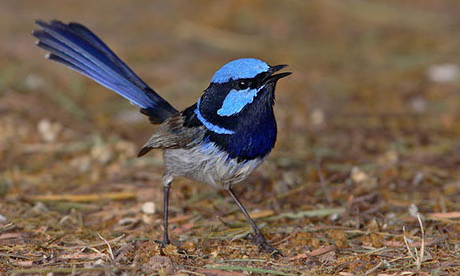

In [ ]:
#| hide
# a picture has no text, so the metadata has to be the text, and it has to be searchable
from fastcore.all import first
from PIL import Image
wren_path = Path.cwd()/'Superb-fairy-wren.-008.avif'
galah_path = Path.cwd()/'galah.webp'
im=Image.open(wren_path);im

In [ ]:
_m,_g = exif_meta(wren_path), exif_meta(galah_path)
_md, _gmd=image_md(_m, 'Superb-fairy-wren.-008', labels=['Superb Fairywren']), image_md(_g, 'galah', labels=['galah'])
assert 'width: 460' in _md
assert 'Superb Fairywren' in _md

In [ ]:
_v = Vault(':memory:')
_r = _v.add_image(wren_path, labels=['Superb Fairywren', 'Malurus cyaneus'])
test_eq(_v.stats()['by_kind']['image'], 1)
test_eq(_v.doc(str(wren_path.resolve()))['meta']['labels'][0], 'Superb Fairywren')
assert first(_v.search('Superb Fairywren', kind='image')), 'labels have to be searchable'
test_eq(len(_v.add_images(Path.cwd(), force=True)), 2)
test_eq(len(_v.images()), 2)
# what a later model run adds is merged in, and the text is rebuilt so it is searchable too
_ = _v.tag_image(str(galah_path.resolve()), labels=['Galah'], caption='pink and grey')
test_eq(_v.doc(str(galah_path.resolve()))['meta']['labels'], ['Galah'])
assert first(_v.search('pink and grey', kind='image'))

## Try it

In [ ]:
v = Vault(':memory:')
v.add_records([dict(sku='A1', name='Free range eggs', price=4.5),
               dict(sku='B2', name='Oat milk', price=2.1)], 'dairy')
v.search('eggs')[0]['breadcrumb']

In [ ]:
# fossick's json_records walk; harvest pagination uses the same
_pay = {'data': {'items': [{'a': 1}, {'a': 2}, {'a': 3}]}}
test_eq(len(json_records(_pay)), 3)
test_eq(json_records(_pay, with_key=True)[1], 'items')
test_eq(secs('6h'), 21600); test_eq(secs('1w'), 604800); test_eq(secs(90), 90)
test_eq(secs('30m'), 1800); test_eq(secs('2 days'), 172800); test_eq(secs('45s'), 45)
test_eq(secs('1h30m'), 5400); test_eq(secs('90'), 90)
test_fail(lambda: secs('whenever'), contains='not a duration')
w = v.watch('late chunking', action='web', every='1d', n=3)
test_eq(w['params'], dict(n=3))
test_eq(len(v.watches(due_only=True)), 1)
v.unwatch(w['id'])
test_eq(len(v.watches()), 0)


In [ ]:
#| hide
# a mixed tree: a README and a source file, the shape of any repo
from tempfile import mkdtemp
d = Path(mkdtemp())
(d/'README.md').write_text('# fuse\n\nRanks are fused because the legs share no vector space.')
(d/'fuse.py').write_text('def fuse(ranks):\n    "Reciprocal rank fusion over ranked lists."\n    return ranks\n')

r = Vault(':memory:').add_tree(d, connect=False)
test_eq((r.n_docs, r.n_code), (1, 1))                 # the doc to the vault, the source to kosha
test_eq(r.docs.attrgot('title'), ['README'])
assert r.code and not r.code.get('error'), r.code     # kosha answered, not the prose fallback

# code=False leaves the source where it is, and a tree with no source never reaches kosha at all
r = Vault(':memory:').add_tree(d, code=False, connect=False)
test_eq((r.n_code, r.code), (0, None))
test_fail(lambda: Vault(':memory:').add_tree(d/'README.md'), contains='not a directory')

# the graph is rebuilt once at the end, not once per file
r = Vault(':memory:').add_tree(d, connect=True)
assert r.graph['entities'] > 0, r.graph

In [ ]:
#| hide
# `arxiv` routes itself, because the *method* fixes the kind and `grab` would route it anyway
v2 = Vault(':memory:')
test_eq(v2.route('arxiv').name, 'papers')
# ...and nothing else does
v2.add_records([dict(sku='A1', name='free range eggs')], 'groceries')
test_eq(v2.doc('records:groceries')['title'], 'groceries')       # right here, where `find` looks
assert v2.search('free range eggs')
(d/'b.py').write_text('def fuse(x):\n    return x\n')
v2.code(d)
assert 'b' in v2.sources(kind='code').attrgot('title')   # filed here, as `kind='code'` prose
# an explicit shelf is never overruled: what was asked for is what happens
test_eq(v2.shelf('sanskrit', offline=True).route('arxiv').name, 'sanskrit')

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()